In [3]:
import os
from ...module.config_local import dir_notebook, dir_raw
from module.misc import sample_name_import
import module.quality_control as qc
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from scipy import stats


ImportError: attempted relative import with no known parent package

# Descriptive statistics

In [ ]:
name_dir = "circa-SD"
samples_ids = sample_name_import(name_dir)
samples_ids

In [ ]:
qc.desc_metrics(samples_ids,
             name_dir,
             reference = False,
             plot_average=False,
             save_plot=False)

### Compare two groups

In [ ]:
# Separate samples ids or load new set of ids
samples_ctrl = samples_ids[0:6]
samples_expe = samples_ids[6:12]

samples_ctrl = sample_name_import("all-samples")
samples_expe = sample_name_import("circa-SD")

In [ ]:
qc.desc_metrics_double(samples_ids_1 = samples_ctrl,
                       samples_ids_2= samples_expe,
                       name_dir = name_dir,
                       reference = False,
                       save_plot=False)

# Noise

In [ ]:
sample = 'hLiver-cancer'

print('Start Sample :', sample)

df = pd.read_parquet(f'D:/Xenium/{sample}/transcripts.parquet',
                        filters=[("qv",">=",20)]
                        )       

# df['id_bis'] = "ASSIGNED"
# df['id_bis'] = df['cell_id'].map({'UNASSIGNED':"UNASSIGNED"})
# df['id_bis'] = df['id_bis'].fillna('ASSIGNED')
# ass_unass = df.groupby('id_bis')['feature_name'].value_counts(sort=False)


data = pd.DataFrame({'feature_name': df.feature_name.value_counts().index,'count' : df.feature_name.value_counts()})
data.sort_index(inplace=True)

# data["UNASSIGNED"] =  ass_unass["UNASSIGNED"]
# data['UNASSIGNED'] = data['UNASSIGNED'].fillna(0)
# data["ASSIGNED"] =  ass_unass["ASSIGNED"]
# data['ASSIGNED'] = data['ASSIGNED'].fillna(0)
# data['ratio_un'] = data['UNASSIGNED'] / data['count']
data['type'] = data['feature_name'].apply(lambda x: x.split('_')[0])

percentile_threshold:float = 99.5
threshold = np.percentile(data[(data['type']=="NegControlProbe") or (data['type']=="NegControlCodeword")]['count'].values,percentile_threshold)
print('threshold = ', threshold)

data['logfoldovernoise'] = data['count'].apply(lambda x: np.log(x / threshold))

# Slide by slide gene expression comparison

In [ ]:
import pandas as pd


name_dir = "all-samples-C123"
# run_to_analyze = 'circa4'

df = pd.read_parquet(f'{dir_notebook}/csv/{name_dir}/{name_dir}_norm_combined.parquet')

Slide_dict = {
    'ZT01': 'Light', 'ZT05': 'Light', 'ZT09': 'Light',
    'ZT13': 'Dark', 'ZT17': 'Dark', 'ZT21': 'Dark'
}

df['Slide'] = df['ZT'].map(Slide_dict)

In [ ]:
df.groupby('Genotype')['Gfap'].mean()

In [ ]:
from module.misc import genes_list

marker_genes = genes_list('brain_panel') ### Extract all genes. If you want a selected list, use genes_list() (module.misc)

grouped_means = df.groupby(['Genotype'])[marker_genes].mean()



In [ ]:
### Count number of genes higher in slide 2 (probably unefficient...)
a=0
for gene in range(len(grouped_means.columns)):
    if grouped_means.iloc[0,gene] < grouped_means.iloc[1,gene]:
        a+=1
print(a)

In [ ]:
grouped_means = grouped_means.T
grouped_means['Diff'] = grouped_means['Dark'] - grouped_means['Light']
plt.scatter(x=range(len(grouped_means)), y=grouped_means['Diff'].sort_values())
plt.hlines(y=0, xmin = 0, xmax=5007, colors='black')
plt.vlines(x=5006/2, ymin=-0.15, ymax=0.15, colors='black')
plt.title(f'{run_to_analyze}: Slide 1 vs Slide 2 Gene expression average')

# MapMyCells Correlation coefficient

In [5]:
name_dir = 'SD1'
samples_ids = sample_name_import(name_dir)

SD1-ZT01
SD1-ZT05
SD1-ZT09
SD1-ZT13
SD1-ZT17
SD1-ZT21


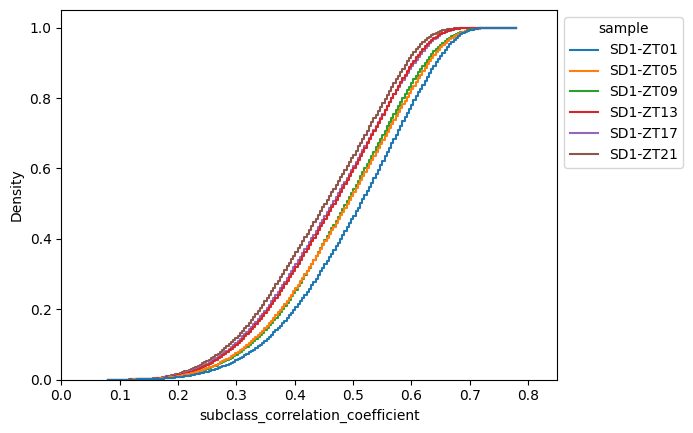

In [7]:
qc.plot_mcc_density(samples_ids,
                    name_dir,
                 save_plot = False,
                 )

# Scatter plot and correlation (2 samples comparison)

In [10]:
sample_CTRL = "circa4-Salk-ZT01"

transcript_count_CTRL = pd.read_parquet(f'{dir_raw}/{sample_CTRL}/transcripts.parquet',
                                         columns=['feature_name'],
                                        filters = [("qv", ">=", 20.0), ("cell_id", "!=","UNASSIGNED")],
                                        dtype_backend = 'pyarrow'

                                         )

transcript_count_CTRL = transcript_count_CTRL[(~transcript_count_CTRL['feature_name'].str.contains('_'))]
transcript_count_CTRL = transcript_count_CTRL['feature_name'].value_counts()
transcript_count_CTRL = transcript_count_CTRL.sort_index()

In [11]:
sample_TEST = "SD1-ZT01"

transcript_count_TEST = pd.read_parquet(f'{dir_raw}/{sample_TEST}/transcripts.parquet',
                                        columns=['feature_name'],
                                        filters = [("qv", ">=", 20.0), ("cell_id", "!=","UNASSIGNED")],
                                        dtype_backend = 'pyarrow'
                                        )

transcript_count_TEST = transcript_count_TEST[(~transcript_count_TEST['feature_name'].str.contains('_'))]
transcript_count_TEST = transcript_count_TEST['feature_name'].value_counts()
transcript_count_TEST = transcript_count_TEST.sort_index()

In [12]:
d = {'CTRL' : transcript_count_CTRL.values, 'TEST' : transcript_count_TEST.values}
df_percent = pd.DataFrame(data = d, index = transcript_count_TEST.index)
df_percent['Percent'] = df_percent['CTRL'] / df_percent['TEST']

In [13]:
df_percent.sort_values(by='TEST').tail(10),df_percent.sort_values(by='Percent', ascending=True).head(20)

(                CTRL    TEST   Percent
 feature_name                          
 Camk2b        305163  511138  0.597027
 Ywhaz         458777  514407  0.891856
 Map1b         323265  521304  0.620108
 Ndrg4         594692  559205   1.06346
 Gnao1         436277  560387  0.778528
 Sncb          416382  562463  0.740283
 Ckb           422932  592278  0.714077
 Gabbr1        407670  594139  0.686153
 Snap25        591144  712446  0.829739
 Aldoa         573250  887394  0.645993,
               CTRL   TEST   Percent
 feature_name                       
 Apoa4          124    794  0.156171
 Tubb1           42    253  0.166008
 Greb1          391   2154  0.181523
 Ch25h          270   1481  0.182309
 Selp            61    268  0.227612
 Eomes         1119   4805  0.232882
 Crygc           15     64  0.234375
 Hoxd3           36    151  0.238411
 Gal            785   3244  0.241985
 Bcl3           265   1061  0.249764
 Mmp12           62    242  0.256198
 Ifng            39    150      0.26
 

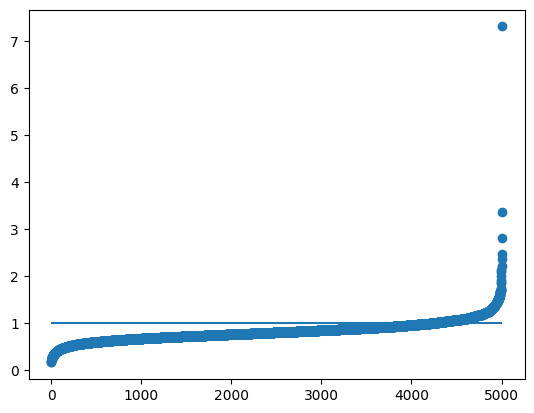

In [14]:
plt.scatter(x=range(len(df_percent['Percent'])), y = df_percent['Percent'].sort_values())
plt.hlines(y=1, xmin=0, xmax=len(df_percent['Percent']))


Text(0.5, 1.0, 'Spearson correlation : 0.982')

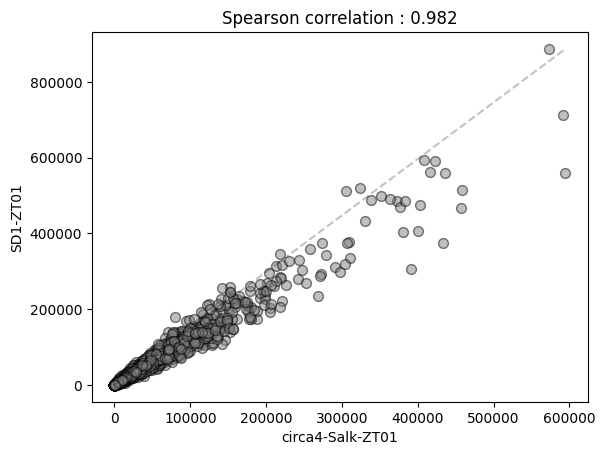

In [17]:
stat_ = stats.pearsonr(x=transcript_count_CTRL, y = transcript_count_TEST)


max_x = max(transcript_count_CTRL)
max_y = max(transcript_count_TEST)

plt.scatter(x=transcript_count_CTRL, y = transcript_count_TEST, s=50, alpha = 0.50, color = 'grey', edgecolors='black')
plt.xlabel(sample_CTRL)
plt.ylabel(sample_TEST)
plt.plot([0, max_x], [0, max_y], linestyle = 'dashed', color = 'black', alpha = 0.24)
plt.title(f'Spearson correlation : {round(stat_[0],3)}')
# plt.savefig(f'/media/volume/volume_spatial/hugo/notebook/plot/correlation_scatter/{sample_CTRL}_v_{sample_TEST}_scatter_correlation.svg')

In [18]:
### Check the difference of rank between genes

CTRL_df = pd.DataFrame(transcript_count_CTRL)
CTRL_df = CTRL_df.sort_values(by='count', ascending=False)
CTRL_df['rank'] = range(len(CTRL_df))
CTRL_df['rank'] +=1
ctrl_dict = dict(zip(CTRL_df.index, CTRL_df['rank']))


TEST_df = pd.DataFrame(transcript_count_TEST)
TEST_df = TEST_df.sort_values(by='count', ascending=False)
TEST_df['rank'] = range(len(TEST_df))
TEST_df['rank'] +=1
test_dict = dict(zip(TEST_df.index, TEST_df['rank']))

In [19]:
CTRL_genes = set(transcript_count_CTRL.index)
TEST_genes = set(transcript_count_TEST.index)
common_genes_list = list(CTRL_genes.intersection(TEST_genes))

In [20]:
temp_CTRL = []
temp_TEST = []
for gene in common_genes_list:
    temp_CTRL.append(transcript_count_CTRL[gene])
    temp_TEST.append(transcript_count_TEST[gene])

In [21]:
d = {'CTRL' : temp_CTRL, 'TEST' : temp_TEST}
df = pd.DataFrame(data = d, index = common_genes_list)


df['rank_CTRL'] = df.index.map(ctrl_dict)
df['rank_TEST'] = df.index.map(test_dict)
df['diff_rank'] = abs(df['rank_CTRL'] - df['rank_TEST'])

df.sort_values(by='diff_rank').tail(10),df.sort_values(by='CTRL').tail(10)

(          CTRL   TEST  rank_CTRL  rank_TEST  diff_rank
 Crym     19927  43397       1578        906        672
 Tac2      5446  15852       2801       2076        725
 Hif3a     3488  11648       3129       2398        731
 Gpr101    6334  17804       2698       1957        741
 Trh       7399  19709       2582       1837        745
 Slc17a6  31019  20459       1037       1791        754
 Ctsl     38497  24768        811       1568        757
 Drd2      9982  25454       2329       1545        784
 Shox2     3744    512       3075       3993        918
 Hspa1b   13689   4872       1993       3044       1051,
           CTRL    TEST  rank_CTRL  rank_TEST  diff_rank
 Gabbr1  407670  594139         10          3          7
 Sncb    416382  562463          9          5          4
 Ckb     422932  592278          8          4          4
 Ldhb    433829  374241          7         25         18
 Gnao1   436277  560387          6          6          0
 Rtn3    457378  467311          5       

Text(0.5, 1.0, 'Distribution of gene rank difference (circa4-Salk-ZT01 vs SD1-ZT01)')

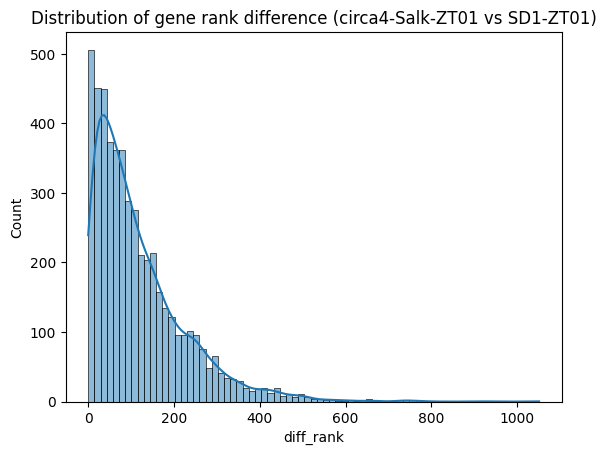

In [24]:
sns.histplot(df['diff_rank'], kde=True)
plt.title(f'Distribution of gene rank difference ({sample_CTRL} vs {sample_TEST})')


# Multi-sample Transcript correlation (one reference)

In [ ]:
### Use Matrix correlation for better multi-sample comparison ###

In [25]:
dir_notebook = '/media/volume/volume_spatial/hugo/notebook'

# # ### circa2_
samples = ['circa2-ZT01','circa2-ZT05','circa2-ZT09','circa2-ZT13','circa2-ZT17','circa2-ZT21']
samples_ids = ['circa2_ZT01','circa2_ZT05','circa2_ZT09','circa2_ZT13','circa2_ZT17','circa2_ZT21',]
name_dir = 'circa2'

# samples = ["S1_Region1", "S1_Region2", "S2_Region1","S2_Region2"]
# samples_ids = ["S1-Region1", "S1-Region2", "S2-Region1","S2-Region2"]
# name_dir = "last_test"

# dir_ = {'circa2-ZT01' : "/media/volume/volume_spatial/hugo/data",
#         'circa2-ZT05' : "/media/volume/volume_spatial/hugo/data",
#         'circa2-ZT09' : "/media/volume/volume_spatial/hugo/data",
#         'circa2-ZT13' : "/media/volume/volume_spatial/hugo/data",
#         'circa2-ZT17' : "/media/volume/volume_spatial/hugo/data",
#         'circa2-ZT21' : "/media/volume/volume_spatial/hugo/data",
#         "S1_Region1" : '/media/volume/volume_spatial/hugo/data',
#         "S1_Region2" : '/media/volume/volume_spatial/hugo/data',
#         "S2_Region1" : '/media/volume/volume_spatial/hugo/data',
#         "S2_Region2" : '/media/volume/volume_spatial/hugo/data',
#         "3159-1" : '/media/volume/volume_spatial/hugo/data',
#         "3160-1" : '/media/volume/volume_spatial/hugo/data'
#        }

dir_ = "/media/volume/volume_spatial/hugo/data"

In [26]:
# samples = ['circa2-ZT01','circa2-ZT05','circa2-ZT09','circa2-ZT13','circa2-ZT17','circa2-ZT21']
# samples_ids = ['circa2_ZT01','circa2_ZT05','circa2_ZT09','circa2_ZT13','circa2_ZT17','circa2_ZT21',]

samples = ['3159-2', "3160-1", "3159-1", "3161-1",]
samples_ids = ['3159-2', "3160-1", "3159-1", "3161-1",]
dir_ = 'D:\\Xenium'

# samples_ids = ['circa4-Salk-ZT01','circa4-Salk-ZT05','circa4-Salk-ZT09',
#                'circa4-Salk-ZT13','circa4-Salk-ZT17','circa4-Salk-ZT21',
#                'circa4-IGM-ZT01','circa4-IGM-ZT05','circa4-IGM-ZT09',
#                'circa4-IGM-ZT13','circa4-IGM-ZT17','circa4-IGM-ZT21',]

# samples = ['circa4-Salk-ZT01','circa4-Salk-ZT05','circa4-Salk-ZT09',
#                'circa4-Salk-ZT13','circa4-Salk-ZT17','circa4-Salk-ZT21',
#                'circa4-IGM-ZT01','circa4-IGM-ZT05','circa4-IGM-ZT09',
#                'circa4-IGM-ZT13','circa4-IGM-ZT17','circa4-IGM-ZT21',]



def top_genes_():
    list_ = []
    for sample, sample_id in zip(samples, samples_ids):
        transcript_count = pd.read_parquet(f'{dir_}/{sample}/transcripts.parquet',
                                            columns=['feature_name'],
                                            filters = [("qv", ">=", 20.0)],
                                            dtype_backend = 'pyarrow'
                                            )

        transcript_count = transcript_count[(~transcript_count['feature_name'].str.contains('_'))
                                            ]
        transcript_count = transcript_count['feature_name'].value_counts()
        transcript_count = transcript_count.sort_index()
        list_.append(transcript_count)

    return list_

def top_genes_assigned():
    list_ = []
    for sample, sample_id in zip(samples, samples_ids):
        transcript_count = pd.read_parquet(f'{dir_}/{sample}/transcripts.parquet',
                                            columns=['feature_name'],
                                            filters = [("qv", ">=", 20.0), ('cell_id',"!=","UNASSIGNED")],
                                            dtype_backend = 'pyarrow'
                                            )

        transcript_count = transcript_count[(~transcript_count['feature_name'].str.contains('_'))]
        transcript_count = transcript_count['feature_name'].value_counts()
        transcript_count = transcript_count.sort_index()
        list_.append(transcript_count)

    return list_
        

In [27]:
test = top_genes_()

In [28]:
from scipy import stats

ref = 0

def spearcor_(test_list):
    nb_sample = len(test_list)
    dict_list = {}
    for n in range(0,nb_sample):
        stat_ = stats.pearsonr(x=test_list[ref].sort_index(), y = test_list[n].sort_index())
        dict_temp = {samples[n]:round(stat_[0],3)}
        dict_list.update(dict_temp)

    return dict_list

In [29]:
dict_list = spearcor_(test)

In [32]:
import matplotlib.pyplot as plt
def plot_coor(dict_list, save_fig = False):
    x = list(dict_list.keys())
    y = list(dict_list.values())
    low = min(y) - 0.05
    high = max(y) + 0.05
    plt.bar(x,y, color = "lightblue", edgecolor = 'black')
    plt.ylim(0,high)
    plt.hlines(y=1, xmin=-0.5,xmax=12.5, linestyles='dashed', colors = 'black')
    plt.title(f'Spearman correlation of genes order compared to {samples_ids[ref]}')
    plt.tick_params(axis = "x", rotation=90, pad = -90, direction = "in")
    if save_fig:
        plt.savefig(f'plot/spearman_correlation_ref_{samples_ids[ref]}.svg')

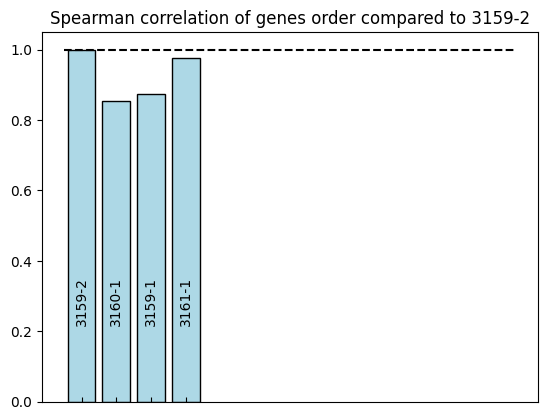

In [33]:
plot_coor(dict_list)

# Matrix SCC multi-sample

In [ ]:
samples = samples_ids = [
    # 'circa2-ZT01','circa2-ZT05'
    # ,'circa2-ZT09',
                        #  'circa2-ZT13','circa2-ZT17','circa2-ZT21',
                         'circa4-Salk-ZT01','circa4-Salk-ZT05','circa4-Salk-ZT09',
                         'circa4-Salk-ZT13','circa4-Salk-ZT17','circa4-Salk-ZT21',
                         'circa4-IGM-ZT01','circa4-IGM-ZT05','circa4-IGM-ZT09',
                         'circa4-IGM-ZT13','circa4-IGM-ZT17','circa4-IGM-ZT21',
                         "SD1-ZT01","SD1-ZT05","SD1-ZT09","SD1-ZT13","SD1-ZT17","SD1-ZT21",
                         ]




# name_dir = 'circa-5k'
# dir_ = "/media/volume/volume_spatial/hugo/data"
dir_ = 'D:\\Xenium'

# samples = samples_ids = ["SD1-ZT01","SD1-ZT05","SD1-ZT09","SD1-ZT13","SD1-ZT17","SD1-ZT21",]
name_dir = 'SD1'
# dir_ = 'E:\\Xenium_SD'

# samples = samples_ids = ['S1_Region_1','S1_Region_2','S2_Region_1','S2_Region_2',]
# name_dir = 'march-test'
# dir_ = 'H:\\march-test'

In [ ]:
import numpy as np
import pandas as pd
from scipy import stats

d = {}

for sample in samples:
    d_temp = {sample : np.zeros(len(samples))}
    d.update(d_temp)

df = pd.DataFrame(d, index = samples)

In [ ]:
df

In [ ]:
def top_genes_():
    list_ = []
    for sample in samples:
        print(sample)
        transcript_count = pd.read_parquet(f'{dir_}/{sample}/transcripts.parquet',
                                           columns=['feature_name'],
                                           filters = [("qv", ">=", 20.0)])
        transcript_count = transcript_count[~transcript_count['feature_name'].str.contains('_')]
        transcript_count = transcript_count['feature_name'].value_counts()
        transcript_count = transcript_count.sort_index()
        # transcript_count = transcript_count.isin(clockgenelist)
        list_.append(transcript_count)

    return list_


def spearcor_(test_list):
    nb_sample = len(test_list)
    dict_list = {}
    for n in range(0,nb_sample):
        stat_ = stats.pearsonr(x=test_list[ref].sort_index(), y = test_list[n].sort_index())
        dict_temp = {samples[n]:round(stat_[0],3)}
        dict_list.update(dict_temp)
    return dict_list

In [ ]:
test_list = top_genes_()

In [ ]:
test_list[0]

In [ ]:
correlation_matrix = pd.DataFrame(index=samples, columns=samples)

for a, sample_ref in enumerate(samples):

   for b, sample_test in enumerate(samples):
      CTRL_genes = set(test_list[a].index)
      TEST_genes = set(test_list[b].index)
      common_genes_list = list(CTRL_genes.intersection(TEST_genes))
      temp_CTRL = []
      temp_TEST = []
      for gene in common_genes_list:
          temp_CTRL.append(test_list[a][gene])
          temp_TEST.append(test_list[b][gene])
      stat_ = stats.pearsonr(x=temp_CTRL, y = temp_TEST)
      
      df[sample_ref][sample_test] = round(stat_[0],3)

     


        

In [ ]:
df.min().min()

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt


matrix = np.triu(df)
np.fill_diagonal(matrix, False)

plt.figure(figsize=(8,8))
sns.heatmap(df, annot=True, cmap="YlGnBu", fmt=".2f", cbar = False,
             mask = matrix,
             vmin= 0.9, vmax= 1,
            )
plt.tick_params(axis='y',rotation= 0)

# plt.savefig('Gallery/pearson_correlation_matrix_circa.svg')


# Kolmogorov–Smirnov test

In [ ]:
import pandas as pd
from scipy import stats
import matplotlib.pyplot as plt
import seaborn as sns

In [49]:
gene = 'Slc17a7'
df = pd.read_parquet('../../csv/circa/circa_norm_combined.parquet',
                      columns=['cell_id','run',gene],
                      filters = [
                          ("run", "=", 'circa4'), ("ZT","=","ZT17"),
                                 ("cell_type_final","=","Pericyte")
                                ])

In [50]:
df1 = df[df['cell_id'].str.contains('IGM')]
df2 = df[df['cell_id'].str.contains('Salk')]

In [51]:
df.shape, df1.shape, df2.shape

((3668, 3), (1701, 3), (1967, 3))

In [52]:
sample1 = df1[gene]
sample1 = sample1 / sample1.max()

sample2 = df2[gene]
sample2 = sample2 / sample2.max()

In [53]:
ks_val = stats.ks_2samp(sample1, sample2, alternative="two-sided")[1]
ks_val

0.0003136622372696069

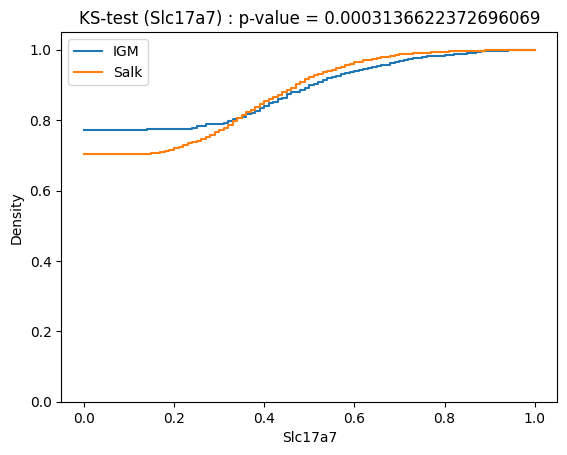

In [55]:
sns.histplot(sample1, element="step", cumulative= True, fill= False, common_norm=False,
             stat='density', label = "IGM", bins = 100)
sns.histplot(sample2, element="step", cumulative= True, fill= False, common_norm=False,
             stat='density', label = "Salk", bins = 100)
plt.title(f'KS-test ({gene}) : p-value = {ks_val}')
plt.ylim(0,1.05)
plt.legend()

## Multi genes

In [ ]:
from module.misc import genes_list
from IPython.display import clear_output
import pandas as pd
from scipy import stats
import matplotlib.pyplot as plt
import seaborn as sns

gene_list = genes_list('panel_5k')
# gene_list = top_genes

gene_dict = {}

df_ks = []

count = 0
total = len(gene_list)

for gene in gene_list:
    count += 1
    print(gene)
    print(count,'/',total)
    dict_temp = {}
    df = pd.read_parquet('../../csv/circa-SD/circa-SD_norm_combined.parquet', columns=['cell_id','run',gene],
                         filters = [#("run", "=", 'circa4'),
                                    ("ZT","=","ZT01"),
                                    ('region_automap_name','=','SCH')
                                    # ("cell_type_final","=","Microglia")
                                    ])
    df1 = df[df['cell_id'].str.contains('IGM')]
    df2 = df[df['cell_id'].str.contains('circa4')]
    sample1 = df1[gene]
    # sample1 = sample1 / sample1.max()
    sample2 = df2[gene]
    # sample2 = sample2 / sample2.max()
    ks_val = stats.ks_2samp(sample1, sample2, alternative="two-sided")[1]
    dict_temp = {gene : ks_val}
    gene_dict.update(dict_temp)
    clear_output()

# df_ks = pd.DataFrame(data = gene_dict, index=gene_list)

In [ ]:
df_ks = pd.Series(gene_dict)

In [ ]:
df_ks

In [ ]:
dir_ = 'D:\\Xenium'
transcript_count_CTRL = pd.read_parquet(f'{dir_}/circa4-IGM-ZT01/transcripts.parquet',
                                         columns=['feature_name'],
                                         filters = [('qv','>=',20.0)]
                                        )                                         

transcript_count_CTRL = transcript_count_CTRL[(~transcript_count_CTRL['feature_name'].str.contains('_'))]
transcript_count_CTRL = transcript_count_CTRL['feature_name'].value_counts()
transcript_count_CTRL = transcript_count_CTRL.sort_index()

d_dict = {"gene_exp":transcript_count_CTRL.values,
          "KS-pval" : df_ks.values}

d = pd.DataFrame(data = d_dict, index = gene_list)
d = d.dropna()

# stat_pearsonr = stats.pearsonr(x=d['gene_exp'], y = d['KS-pval'])
# stat_pearsonr

stat_spearmanr = stats.spearmanr(a=d['gene_exp'], b = d['KS-pval'])
stat_spearmanr

In [ ]:
sns.set_theme() 

fig, axes = plt.subplots(2,3, figsize = (15,10))
fig.tight_layout()
fig.delaxes(axes[1,2])

sns.histplot(df_ks.values, element="step", cumulative= True, fill= False, common_norm=False,
             stat='density', alpha = 0.75, ax = axes[0,0])
axes[0,0].set_ylim(0,1.01)
axes[0,0].vlines(x=0.05, ymin = 0, ymax= 1, linestyles='dashed',color = "red", label = "Statistical significance")
axes[0,0].set_xlabel('Kolmogorov-Smirnov test p-value')
axes[0,0].legend()

sns.boxplot(y=df_ks.values, ax=axes[0,1], width=0.25, fill = False)
axes[0,1].hlines(y=0.05, xmin = -0.5, xmax=0.5, linestyles='dashed',color = "red", label = "Statistical significance")
axes[0,1].set_ylabel('Kolmogorov-Smirnov test p-value')
# axes[0,1].legend()

sns.scatterplot(data=d, x='gene_exp',y='KS-pval', size = 4, ax = axes[0,2])
axes[0,2].set_xscale('log')
# plt.yscale('log')
axes[0,2].set_xlabel('Gene expression (total)')
axes[0,2].set_ylabel('KS p-value')
axes[0,2].set_title(f'Spearman correlation: r = {round(stat_spearmanr[0],3)}; p-val = {round(stat_spearmanr[1],3)} ')

sns.violinplot(df_ks.values,alpha = 0.75, ax=axes[1,0], cut=0, inner_kws=dict(box_width=10, whis_width=2, color=".8"))
axes[1,0].set_ylabel('Kolmogorov-Smirnov test p-value')


sns.swarmplot(df_ks.values, size = 2.5, ax=axes[1,1])
axes[1,1].hlines(y=0.05, xmin = -0.5, xmax=0.5, linestyles='dashed',color = "red", label = "Statistical significance")
axes[1,1].set_ylabel('Kolmogorov-Smirnov test p-value')
# axes[1,1].legend()

In [ ]:
sns.histplot(sample1, element="step", cumulative= True, fill= False, common_norm=False,
             stat='density')
sns.histplot(sample2, element="step", cumulative= True, fill= False, common_norm=False,
             stat='density')
plt.ylim(0,1.05)
plt.title(f'KS-test ({gene}) : p-value = {ks_val}')

# MA plot (WIP)

In [56]:
import pandas as pd
import matplotlib.pyplot as plt
from module.misc import genes_list
import numpy as np

In [61]:
df = pd.read_parquet(f'{dir_notebook}/csv/all-samples-C123/all-samples-C123_norm_combined.parquet')

In [ ]:
fc = pd.read_csv('../notebook/csv/all-samples-C123/foldchange/all-samples-C123_foldchange_wholesection.csv')
fc_filter = fc

FileNotFoundError: [Errno 2] No such file or directory: '../notebook/csv/all-samples-C123/foldchanges/all-samples-C123_foldchange_wholesection.csv'

In [65]:
marker_genes = genes_list('brain_panel')
grouped = df.groupby(['Genotype'])[marker_genes].mean()
grouped = grouped.T
grouped['diff'] = (grouped['WT'] + grouped['APP']) /2

In [66]:
grouped['names'] = grouped.index

In [67]:
fc.drop(['scores', 'pvals', 'pvals_adj', 'pct_nz_group', 'pct_nz_reference'], axis = 1, inplace = True)

NameError: name 'fc' is not defined

In [ ]:
fc_filter = fc_filter[(abs(fc_filter['logfoldchanges']) > 0.26)]
fc_filter['diff'] = fc_filter['names'].map(dict(zip(grouped['names'],grouped['diff'])))

In [ ]:
grouped['logfoldchange'] = grouped['names'].map(dict(zip(fc['names'],fc['logfoldchanges'])))

In [ ]:
grouped['logdiff'] = np.log2(abs(grouped['diff']))

In [ ]:
fc_filter[fc_filter['diff'] > 0.001].sort_values("logfoldchanges")

In [ ]:
plt.scatter(y=grouped['logfoldchange'], x = grouped['diff'], s = 3, alpha =0.75, color = "grey")
plt.scatter(y=fc_filter[fc_filter['diff'] > 0.15]['logfoldchanges'], x = fc_filter[fc_filter['diff'] > 0.15]['diff'], s = 3, alpha =0.75, color = "red")
plt.hlines(y=0, xmax=max(grouped['diff']), xmin=0, color='black')
# plt.xscale("log")
plt.xlabel('Average count')
plt.ylabel('logFC (whole brain)')
plt.title('MA plot')

In [ ]:
import seaborn as sns
sns.histplot(data = grouped, x = 'SD1', fill= False, kde =True, bins = 50,
             stat='density')
sns.histplot(data = grouped, x = 'circa4',  fill= False, kde =True, bins = 50,
             stat='density')
plt.xlim(0,1)